# EDA

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

In [26]:
df = pd.read_csv('./data/UCI_Credit_Card.csv')

display(df.head())
display(df.info())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

None

,Count,Percentage (%)
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


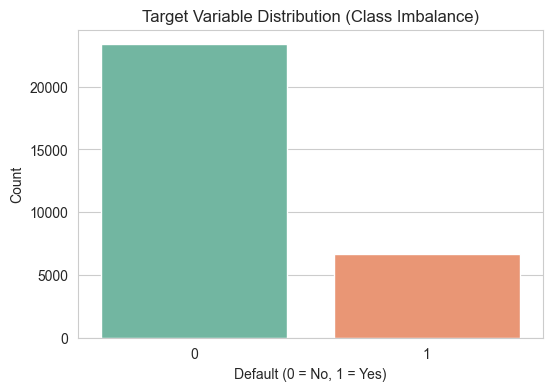

In [27]:
target_col = 'default.payment.next.month'
if target_col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col, palette='Set2')
    plt.title('Target Variable Distribution (Class Imbalance)')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel('Count')
    
    counts = df[target_col].value_counts()
    percentages = df[target_col].value_counts(normalize=True) * 100
    display(pd.DataFrame({'Count': counts, 'Percentage (%)': percentages}))
else:
    print(f"Target column '{target_col}' not found. Check column names.")

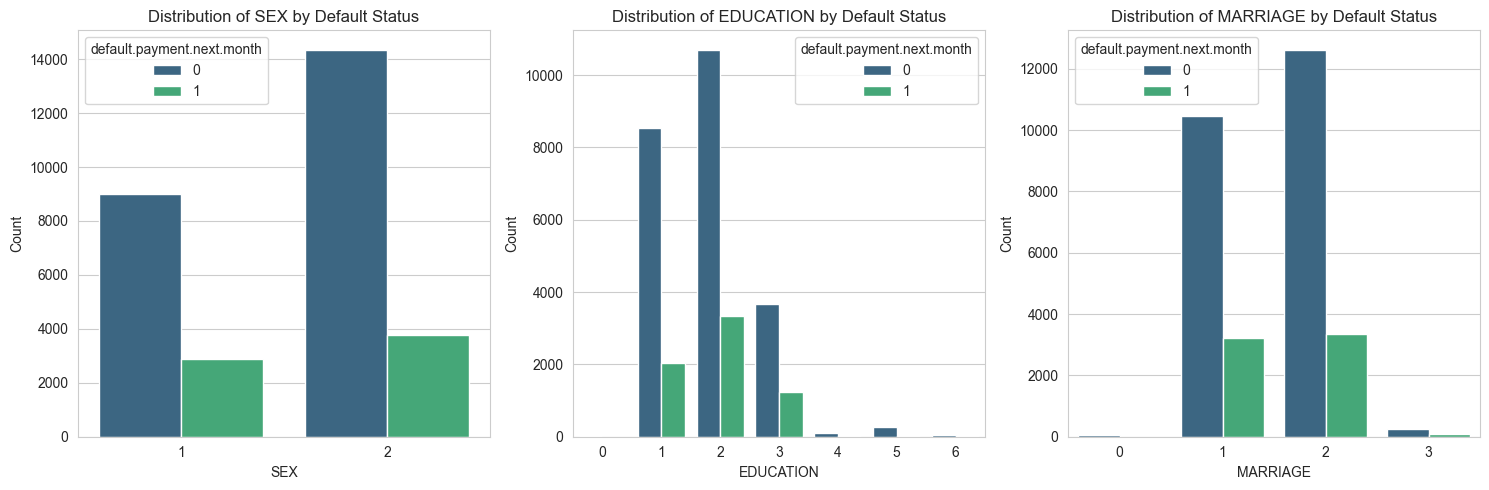

In [28]:
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_features, 1):
    if col in df.columns:
        plt.subplot(1, 3, i)
        sns.countplot(data=df, x=col, hue=target_col, palette='viridis')
        plt.title(f'Distribution of {col} by Default Status')
        plt.ylabel('Count')

plt.tight_layout()
plt.show()

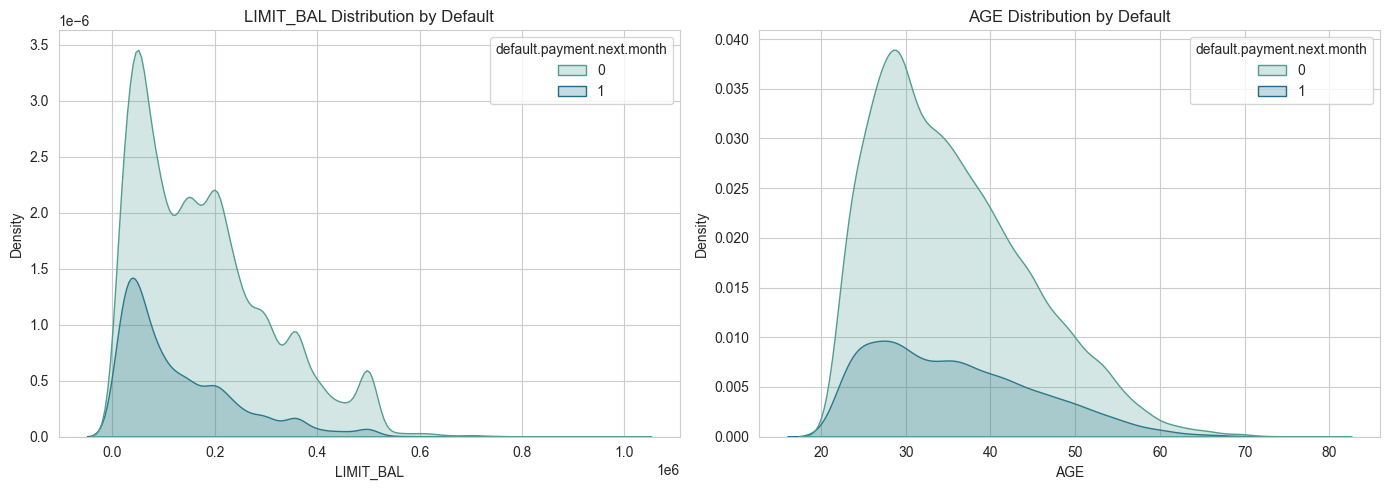

In [29]:
numerical_features = ['LIMIT_BAL', 'AGE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(numerical_features):
    if col in df.columns:
        sns.kdeplot(data=df, x=col, hue=target_col, fill=True, ax=axes[i], palette='crest')
        axes[i].set_title(f'{col} Distribution by Default')

plt.tight_layout()
plt.show()

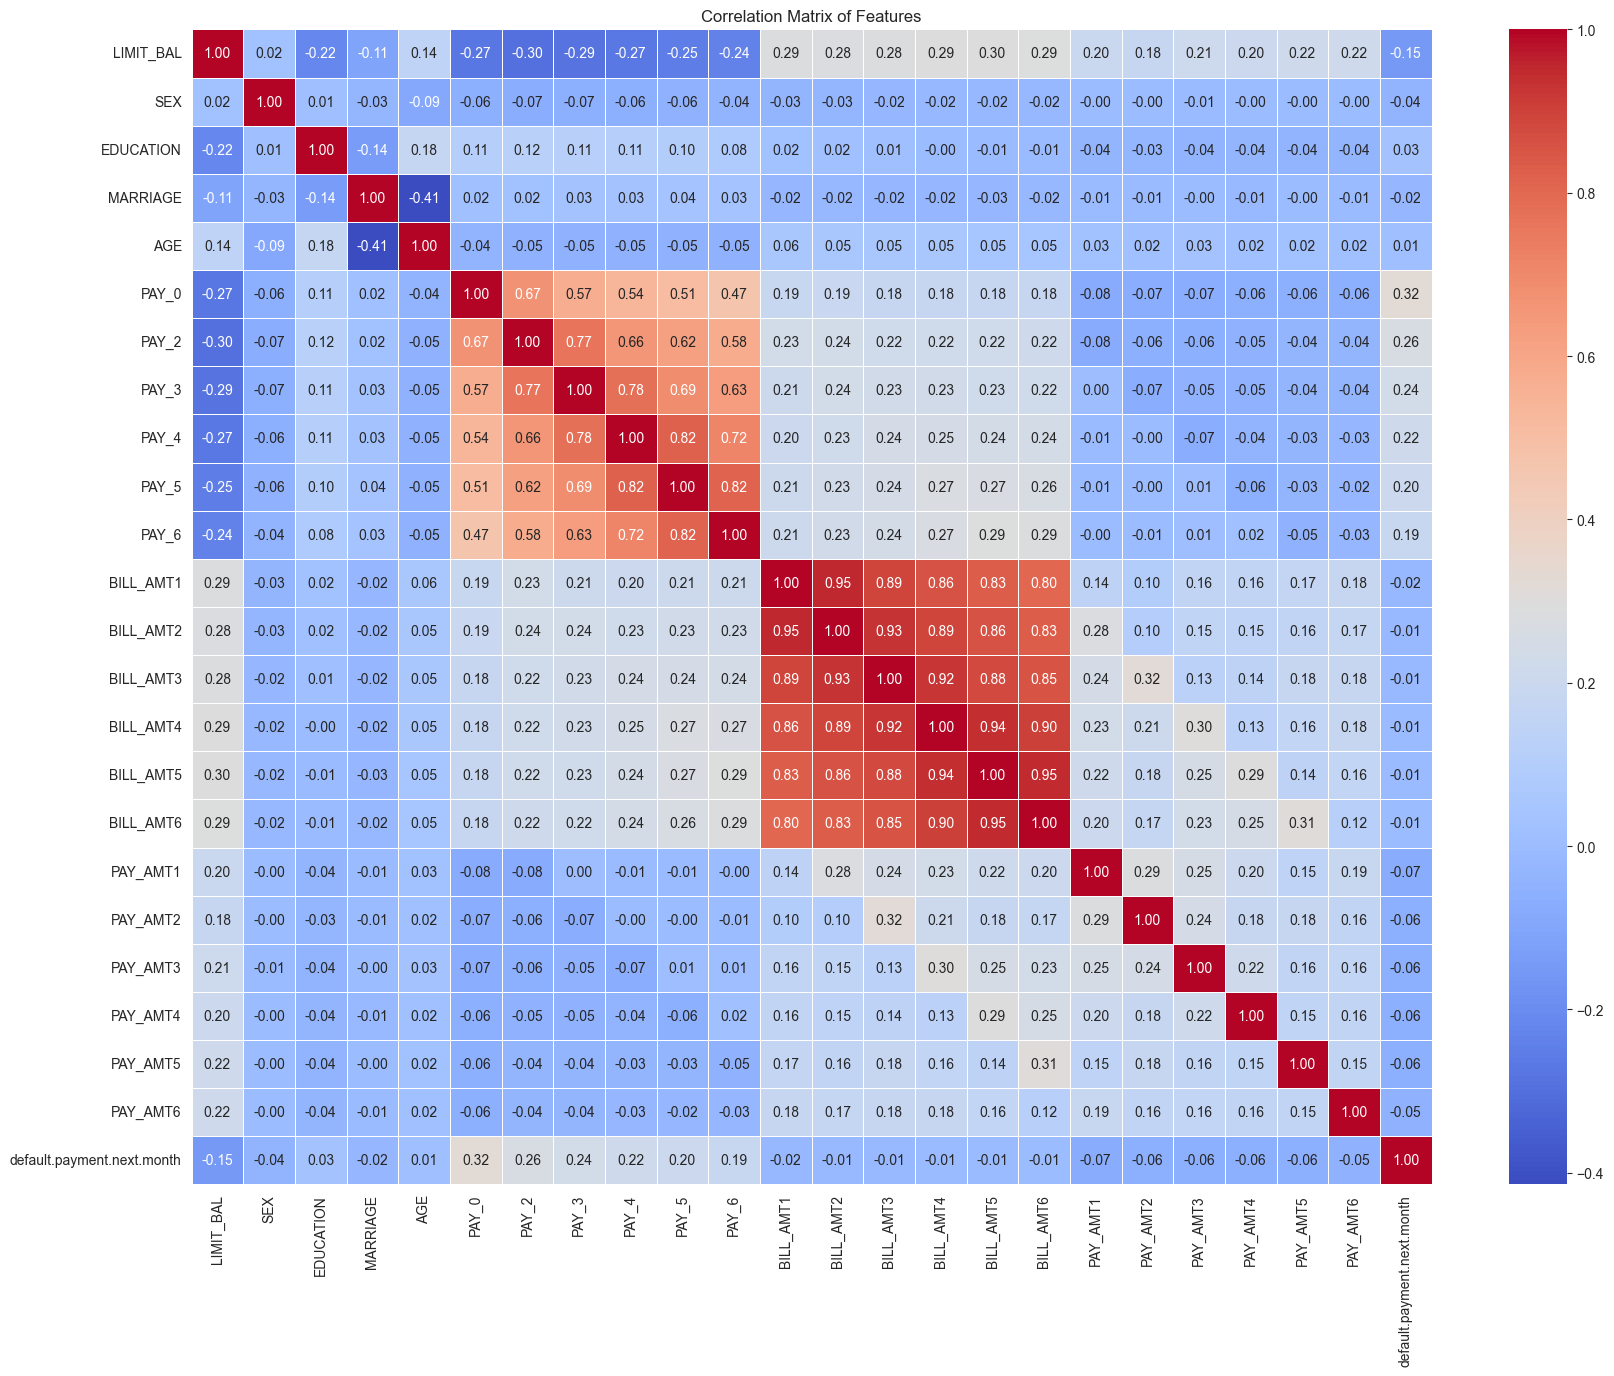

In [30]:
plt.figure(figsize=(20, 15))

cols_to_drop = ['ID'] if 'ID' in df.columns else []
corr = df.drop(columns=cols_to_drop).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

## Data Preprocessing

Original training target shape: Counter({0: 18691, 1: 5309})
Resampled training target shape: Counter({0: 18691, 1: 18691})


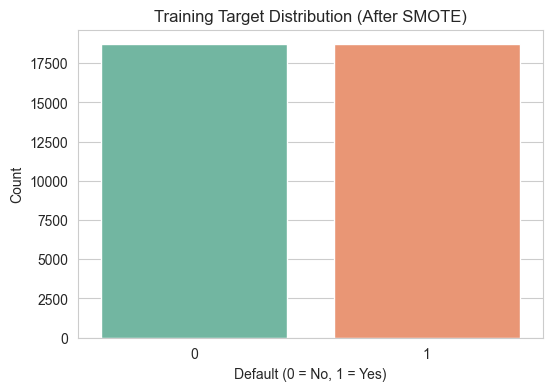

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

if target_col in df.columns:
    X = df.drop(columns=[target_col, 'ID'] if 'ID' in df.columns else [target_col])
    y = df[target_col]
    
    X = pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Original training target shape: {Counter(y_train)}")
    
    # Balance training set
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    print(f"Resampled training target shape: {Counter(y_train_resampled)}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y_train_resampled, palette='Set2')
    plt.title('Training Target Distribution (After SMOTE)')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel('Count')
    plt.show()